In [1]:
!pip install -q sentence-transformers peft datasets faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.3 MB/s eta 0:00:00


In [2]:
!pip install -q --upgrade ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.12.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import shutil
from pathlib import Path

try:
  shutil.rmtree(Path("/content/drive/MyDrive/auto-hh/models/BiEncoder"))
except:
  print('BiEncoder ещё нет')

In [5]:
%cd /content/drive/MyDrive/auto-hh/src
%load_ext autoreload
%autoreload 2

/content/drive/MyDrive/auto-hh/src


In [6]:
import torch
from models import BiEncoder, CrossEncoder
from training import Trainer

In [7]:
MODEL_NAME = "BAAI/bge-m3"
USE_LORA = True

model = BiEncoder(
    model_name=MODEL_NAME,
    use_lora=USE_LORA,
)

print(f"Обучаемых параметров: {model.count_trainable_parameters()}")

if model.count_trainable_parameters() > 10000:
    print("LoRA активна")
else:
    print("Параметров слишком мало")

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Применена LoRA. Обучаемых параметров: 786432 / 568541184
Обучаемых параметров: 786432
LoRA активна


In [7]:
!pip install -q rank_bm25

In [8]:
from lib import create_train_examples

In [10]:
VACANCIES_PATH = "/content/drive/MyDrive/auto-hh/hh_dataset.csv"
RESUMES_PATH = "/content/drive/MyDrive/auto-hh/resumes_generated.csv"

full_dataset = create_train_examples(
    vacancies_path=VACANCIES_PATH,
    resumes_path=RESUMES_PATH,
    max_examples=800
)

Пример данных:
Resume: ВАКАНСИЯ: Frontend Developer (React/TypeScript). ЗАРПЛАТА: 210000 RUB. ОПЫТ: — Frontend Developer в ООО «ТехСервис» (2 г.): Разрабатывал UI‑компоненты на React + TypeScript для CRM‑системы: реестры, формы, модальные окна. Помогал с интеграцией API, писал async thunks, реализовывал optimistic updates. Работал над сложными таблицами с виртуализацией и inline‑редактированием, улучшил производительность рендеринга. Участвовал в code‑review, поддерживал дизайн‑систему MUI, писал тесты в Jest/RTL. — Junior Frontend Engineer в АО «Инновационные Решения» (1 г.): Участвовал в построении дашбордов: графики, виджеты, сохранённые фильтры. Работал над валидацией форм, обрабатывал ошибки загрузки, помогал с настройкой CI/CD веток. Делал небольшие UI‑правки, улучшил пользовательские потоки, иногда писал стили в styled-components.. ОБРАЗОВАНИЕ: Воронежский государственный университет им. М. В. Ломоносова (год выпуска: 2018.0). НАВЫКИ: TypeScript, React, JavaScript, Redux, Git, U

In [11]:
split_dataset = full_dataset.train_test_split(
    test_size=0.2,
    seed=42,
    shuffle=True
)

train_dataset, test_dataset = split_dataset['train'], split_dataset['test']

In [12]:
print(test_dataset)

Dataset({
    features: ['anchor', 'positive'],
    num_rows: 200
})


In [13]:
import torch, gc
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

263

In [10]:
OUTPUT_PATH = "/content/drive/MyDrive/auto-hh/models/BiEncoder"

In [15]:
%%time

trainer = Trainer(
    batch_size=8,
    epochs=1,
    learning_rate=2e-4,
    use_lora=USE_LORA,
)
trainer.train(model, train_dataset, OUTPUT_PATH)


Подготовка данных...
   - Примеров: 1,000
   - Batch size: 16
   - Epochs: 3
   - LoRA enabled: True

Запуск обучения...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
10,1.296525
20,1.106285
30,0.752725
40,0.442131
50,0.297550
60,0.241970
70,0.111200
80,0.125665
90,0.102349


Адаптеры LoRA сохранены в: /content/drive/MyDrive/auto-hh/models/BiEncoder/adapter
CPU times: user 11min 54s, sys: 7min 18s, total: 19min 12s
Wall time: 19min 20s


## 🧪 ПРОВЕРКА ЗАГРУЗКИ И РАБОТЫ БИ ЭНКОДЕРА

In [16]:
!find /content/drive/MyDrive/auto-hh/models/BiEncoder

/content/drive/MyDrive/auto-hh/models/BiEncoder
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/config_sentence_transformers.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/README.md
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/adapter_model.safetensors
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/adapter_config.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/tokenizer_config.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/tokenizer.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/sentence_bert_config.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/1_Pooling
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/1_Pooling/config.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/modules.json
/content/drive/MyDrive/auto-hh/models/BiEncoder/checkpoint-96/training_a

In [11]:
try:
    loaded_model = BiEncoder.load_trained(
        path=OUTPUT_PATH,
        model_name="BAAI/bge-m3",
        use_lora=True
    )
    loaded_model.eval()

    if torch.cuda.is_available():
        loaded_model = loaded_model.to('cuda')

    print(f"Модель загружена из: {OUTPUT_PATH}")
    print(f"Устройство: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
    print(f"Размерность эмбеддинга: {loaded_model.get_sentence_embedding_dimension()}")
except Exception as e:
    print(f"Ошибка загрузки: {e}")
    raise

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Адаптеры LoRA загружены из: /content/drive/MyDrive/auto-hh/models/BiEncoder/adapter
Модель загружена из: /content/drive/MyDrive/auto-hh/models/BiEncoder
Устройство: CUDA
Размерность эмбеддинга: 1024


In [18]:
import pandas as pd
import torch
from sentence_transformers import util


results = []

with torch.no_grad():
    for item in test_dataset:
        emb_r = loaded_model.encode(item["anchor"], convert_to_tensor=True)
        emb_v = loaded_model.encode(item["positive"], convert_to_tensor=True)

        score = util.cos_sim(emb_r, emb_v).item()

        results.append({
            "anchor": item["anchor"],
            "positive": item["positive"],
            "score": score
        })

results_df = pd.DataFrame(results)
results_df.to_csv("test_results.csv", index=False)

print(f"Сохранено {len(results)} результатов в test_results.csv")
print(f"\nСтатистика:")
print(f"Средний скор: {results_df['score'].mean():.4f}")
print(f"Мин/Макс: {results_df['score'].min():.4f} / {results_df['score'].max():.4f}")
print(f"Медиана: {results_df['score'].median():.4f}")

print(f"\nПервые 10 результатов:")
print(results_df.head(10))

Сохранено 200 результатов в test_results.csv

Статистика:
Средний скор: 0.7946
Мин/Макс: 0.4775 / 0.9315
Медиана: 0.7963

Первые 10 результатов:
                                              anchor  \
0  ВАКАНСИЯ: Golang разработчик. ЗАРПЛАТА: 420000...   
1  ВАКАНСИЯ: Senior Frontend Engineer. ЗАРПЛАТА: ...   
2  ВАКАНСИЯ: Senior Frontend Developer (React/Typ...   
3  ВАКАНСИЯ: Менеджер по продажам. ЗАРПЛАТА: 1500...   
4  ВАКАНСИЯ: Product Manager. ЗАРПЛАТА: 210000 RU...   
5  ВАКАНСИЯ: Менеджер проектов по трансграничным ...   
6  ВАКАНСИЯ: Бариста. ЗАРПЛАТА: 70000 RUB. ОПЫТ: ...   
7  ВАКАНСИЯ: Официант. ЗАРПЛАТА: 70 RUB. ОПЫТ: — ...   
8  ВАКАНСИЯ: Python Developer. ЗАРПЛАТА: 210000 R...   
9  ВАКАНСИЯ: Middle Python Engineer (NLP/LLM). ЗА...   

                                            positive     score  
0  ВАКАНСИЯ: Senior Golang developer. ЗАРПЛАТА: Н...  0.805643  
1  ВАКАНСИЯ: Frontend-разработчик React (middle+/...  0.768536  
2  ВАКАНСИЯ: Middle / Senior Frontend Devel

In [15]:
from sentence_transformers import SentenceTransformer, util
import torch

test_resume = """
Python Developer с опытом работы 5 лет.
Умею работать с микросервисной архитектурой, есть знания в FastAPI и Kafka.
Знаю SQL (MySQL)
"""

test_vacancy_match = """
Требуется Senior Python разработчик.
Стек: Django, FastAPI, PostgreSQL.
Опыт с микросервисами и очередями сообщений.
"""

test_vacancy_mismatch = """
Требуется Java разработчик.
Стек: Spring, Hibernate, MySQL.
Опыт работы с корпоративными системами.
"""

emb_resume = loaded_model.encode(test_resume, convert_to_tensor=True)
emb_match = loaded_model.encode(test_vacancy_match, convert_to_tensor=True)
emb_mismatch = loaded_model.encode(test_vacancy_mismatch, convert_to_tensor=True)

sim_match = util.cos_sim(emb_resume, emb_match).item()
sim_mismatch = util.cos_sim(emb_resume, emb_mismatch).item()

print(f"Релевантная пара: {sim_match:.4f}")
print(f"Нерелевантная пара: {sim_mismatch:.4f}")
print(f"Разница: {sim_match - sim_mismatch:.4f}")

if sim_match > sim_mismatch:
    print("Модель работает корректно!")
else:
    print("Модель требует дообучения")
    print("Нерелевантная вакансия имеет больший скор")

if sim_match > 0.5:
    print("Хорошее сходство для релевантной пары")
else:
    print("Низкое сходство (возможно, мало данных для обучения)")

Релевантная пара: 0.7397
Нерелевантная пара: 0.5512
Разница: 0.1885
Модель работает корректно!
Хорошее сходство для релевантной пары


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_test = pd.read_csv('/content/drive/MyDrive/auto-hh/src/test.csv')

In [19]:
model_scores = []
for idx, row in df_test.iterrows():
    emb_resume = loaded_model.encode(row['resume'], convert_to_tensor=True)
    emb_vacancy = loaded_model.encode(row['vacancy'], convert_to_tensor=True)

    sim = util.cos_sim(emb_resume, emb_vacancy).item()
    model_scores.append(sim)

df_test['model_score'] = model_scores

In [29]:
df_test.to_csv('data.csv')

In [20]:
y_true = df_test['objective_score'].values
y_pred = df_test['model_score'].values

In [24]:
spearman_corr, spearman_p = spearmanr(y_true, y_pred)
print(f"\nSpearman Correlation: {spearman_corr:.4f}")

kendall_corr, kendall_p = kendalltau(y_true, y_pred)
print(f"\nKendall Tau: {kendall_corr:.4f}")


Spearman Correlation: 0.8730

Kendall Tau: 0.6841


In [25]:
mae = mean_absolute_error(y_true, y_pred)
print(f"\nMAE: {mae:.4f}")

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"\nRMSE: {rmse:.4f}")

r2 = r2_score(y_true, y_pred)
print(f"\nR² Score: {r2:.4f}")


MAE: 0.1740

RMSE: 0.2162

R² Score: 0.5924


In [26]:
print(f"\nAccuracy на разных порогах:")
for thresh in [0.3, 0.5, 0.7, 0.8]:
    y_true_binary = (y_true >= thresh).astype(int)
    y_pred_binary = (y_pred >= thresh).astype(int)
    accuracy = (y_true_binary == y_pred_binary).mean()
    print(f"   Порог {thresh}: Accuracy = {accuracy:.2%}")


Accuracy на разных порогах:
   Порог 0.3: Accuracy = 71.00%
   Порог 0.5: Accuracy = 89.00%
   Порог 0.7: Accuracy = 86.00%
   Порог 0.8: Accuracy = 81.00%


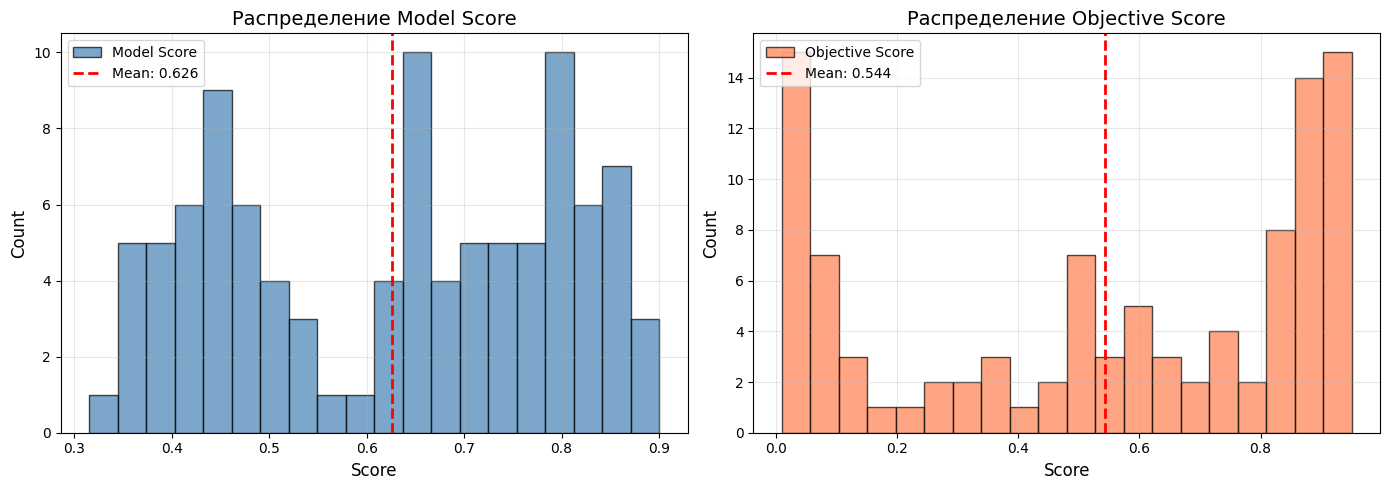

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_test['model_score'], bins=20, alpha=0.7, color='steelblue', edgecolor='black', label='Model Score')
axes[0].axvline(df_test['model_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_test["model_score"].mean():.3f}')
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Распределение Model Score', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_test['objective_score'], bins=20, alpha=0.7, color='coral', edgecolor='black', label='Objective Score')
axes[1].axvline(df_test['objective_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_test["objective_score"].mean():.3f}')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Распределение Objective Score', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print("\n⚡ ТЕСТ СКОРОСТИ:")

import time

n_requests = 10
start = time.time()
for _ in range(n_requests):
    loaded_model.encode([test_resume], convert_to_numpy=True)
end = time.time()

avg_time = (end - start) / n_requests * 1000  # мс
print(f"   Среднее время на запрос: {avg_time:.2f} мс")
print(f"   Запросов в секунду: {1000/avg_time:.1f}")

# ────────────────────────────────────────
print("\n" + "=" * 60)
print("🎉 ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
print("=" * 60)


⚡ ТЕСТ СКОРОСТИ:
   Среднее время на запрос: 28.20 мс
   Запросов в секунду: 35.5

🎉 ТЕСТИРОВАНИЕ ЗАВЕРШЕНО


In [21]:
print("\nТест извлечения весов внимания")
weights = loaded_model.get_attention_weights(test_resume)

top_tokens = sorted(weights.items(), key=lambda x: x[1], reverse=True)[:10]
print("Топ токенов по важности:")
for token, weight in top_tokens:
    print(f"  {token}: {weight:.4f}")


Тест извлечения весов внимания


AttributeError: 'BiEncoder' object has no attribute 'get_attention_weights'

## ТЕСТ КРОСС ЭНКОДЕРА

In [ ]:
# ─── Загрузка ──────────────────────────
print("📥 Загрузка CrossEncoder...")
ce = CrossEncoder("BAAI/bge-reranker-v2-m3")

In [ ]:
query = "Python разработчик Django"
candidates = [
    "Требуется Python разработчик с опытом Django и FastAPI",
    "Вакансия: Java разработчик Spring Boot",
    "Ищем DevOps инженера Kubernetes Docker",
]

scores = ce.rerank(query, candidates)
print(*scores, sep='\n')

# ─── Проверка ──────────────────────────
assert len(scores) == 3, "❌ Количество scores не совпадает!"
assert 0 <= scores[0]["score"] <= 1, "❌ Score вне диапазона!"
print("\n✅ CrossEncoder работает! 🎉")